# 🏠 House Price Prediction

### Advanced Regression Techniques with Machine Learning

This project predicts residential house sale prices using the Ames Housing dataset.

The project follows a complete machine learning workflow:

**EDA → Data Cleaning → Feature Engineering → Preprocessing → Model Comparison → XGBoost Tuning → Final Prediction**

### Models
- Linear Regression
- Random Forest
- XGBoost

### Evaluation Metrics
- RMSE
- MAE
- R²

## 1. Import Libraries

We begin by importing the libraries required for data analysis, visualization,
preprocessing, model training, evaluation, and hyperparameter tuning.

In [6]:
!pip install -q --upgrade kaggle

import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The competition provides training and testing datasets.

- `train.csv` contains the target variable `SalePrice`.
- `test.csv` does not contain `SalePrice`.
- `data_description.txt` provides the meaning of each feature.

The training data will be used for exploration, model development, and validation.
The test data will be used only for the final predictions.

In [7]:
from google.colab import drive
drive.mount("/content/drive")

os.listdir("/content/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['.config',
 'kaggle (2).json',
 'house-prices-advanced-regression-techniques.zip',
 'drive',
 'sample_data']

In [8]:
data=pd.read_csv("/content/kaggle (2).json")

In [9]:
!mkdir -p ~/.kaggle
!cp 'kaggle (2).json' ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c house-prices-advanced-regression-techniques

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)


In [10]:
zip_file = "house-prices-advanced-regression-techniques.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(".")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [11]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

Train: (1460, 81)
Test: (1459, 80)


## 3. Initial Data Exploration

Before preprocessing the data, we inspect its structure, data types,
summary statistics, and first few observations.

In [12]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [14]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Initial Observations

The training dataset contains 1,460 observations and 81 columns.

The target variable is:

`SalePrice`

The dataset contains both numerical and categorical features, as well as
missing values that need to be investigated before modeling.

## 4. Exploratory Data Analysis

The goal of EDA is to understand:

- The distribution of house prices
- Missing-value patterns
- Numerical feature distributions
- Categorical feature distributions
- Relationships between important features and `SalePrice`
- Correlations between numerical variables
- Potential outliers

In [15]:
train["SalePrice"].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


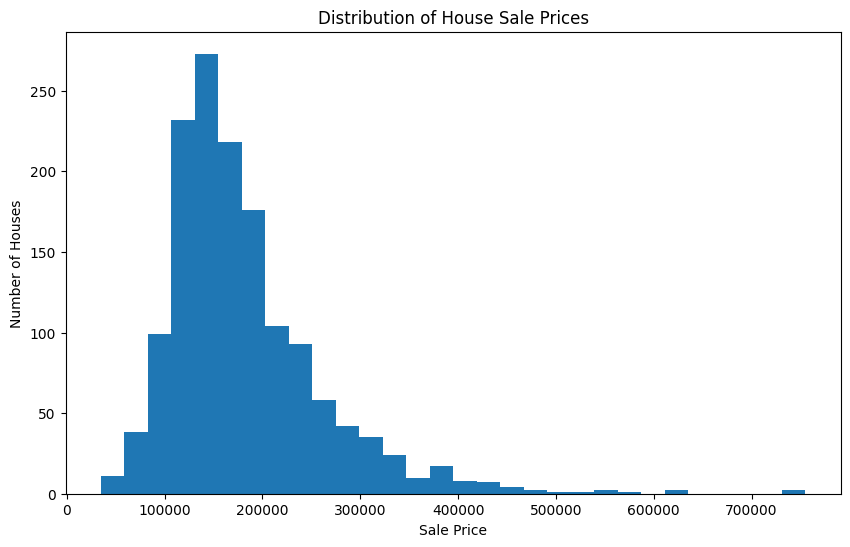

In [57]:
plt.figure(figsize=(10, 6))
plt.hist(train["SalePrice"], bins=30)

plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Sale Prices")

plt.savefig("saleprice_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
from google.colab import files

files.download("saleprice_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
missing_df = pd.DataFrame({
    "Missing_Count": train.isnull().sum(),
    "Missing_Percentage": train.isnull().mean() * 100
})

missing_df = (
    missing_df[missing_df["Missing_Count"] > 0]
    .sort_values("Missing_Percentage", ascending=False)
)

missing_df

,Missing_Count,Missing_Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [18]:
numerical_cols = train.select_dtypes(
    include=["int64", "float64"]
).columns

print("Number of numerical features:", len(numerical_cols))

train[numerical_cols].describe().T

Number of numerical features: 38


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [19]:
categorical_cols = train.select_dtypes(
    include=["object"]
).columns

print("Number of categorical features:", len(categorical_cols))

Number of categorical features: 43


In [20]:
for col in categorical_cols:
    print(f"\n{col}")
    print(train[col].value_counts())


MSZoning
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Street
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Alley
Alley
Grvl    50
Pave    41
Name: count, dtype: int64

LotShape
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

LandContour
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Utilities
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

LotConfig
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

LandSlope
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Neighborhood
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
Clear

## 5. Feature Relationships

We now investigate how important numerical features relate to `SalePrice`.

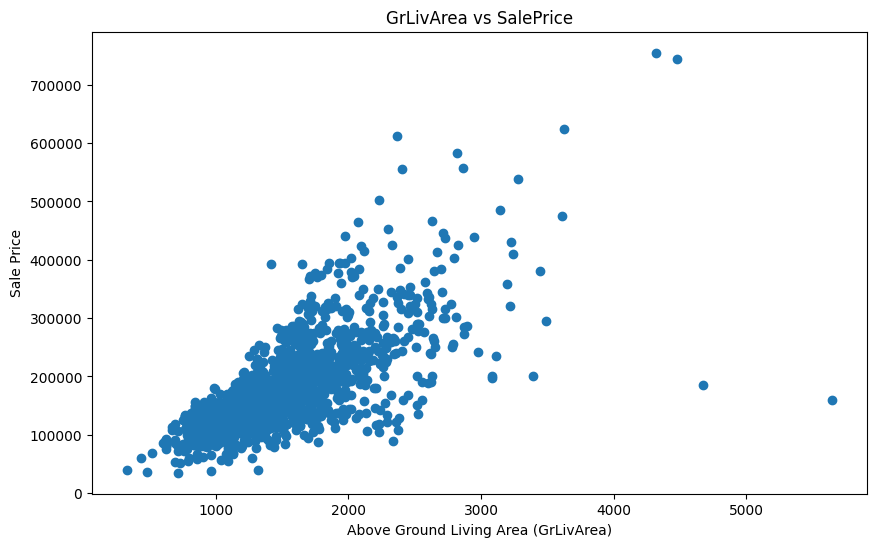

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(train["GrLivArea"], train["SalePrice"])

plt.xlabel("Above Ground Living Area (GrLivArea)")
plt.ylabel("Sale Price")
plt.title("GrLivArea vs SalePrice")

plt.show()

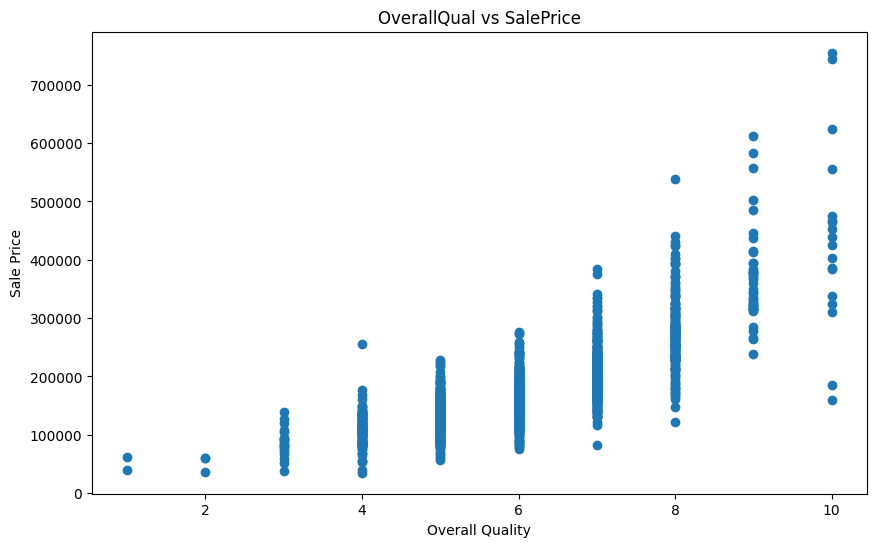

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(train["OverallQual"], train["SalePrice"])

plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("OverallQual vs SalePrice")

plt.show()

## 6. Correlation Analysis

Correlation helps us identify numerical variables that have strong linear
relationships with the target variable.

In [23]:
correlations = (
    train[numerical_cols]
    .corr()["SalePrice"]
    .sort_values(ascending=False)
)

correlations

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


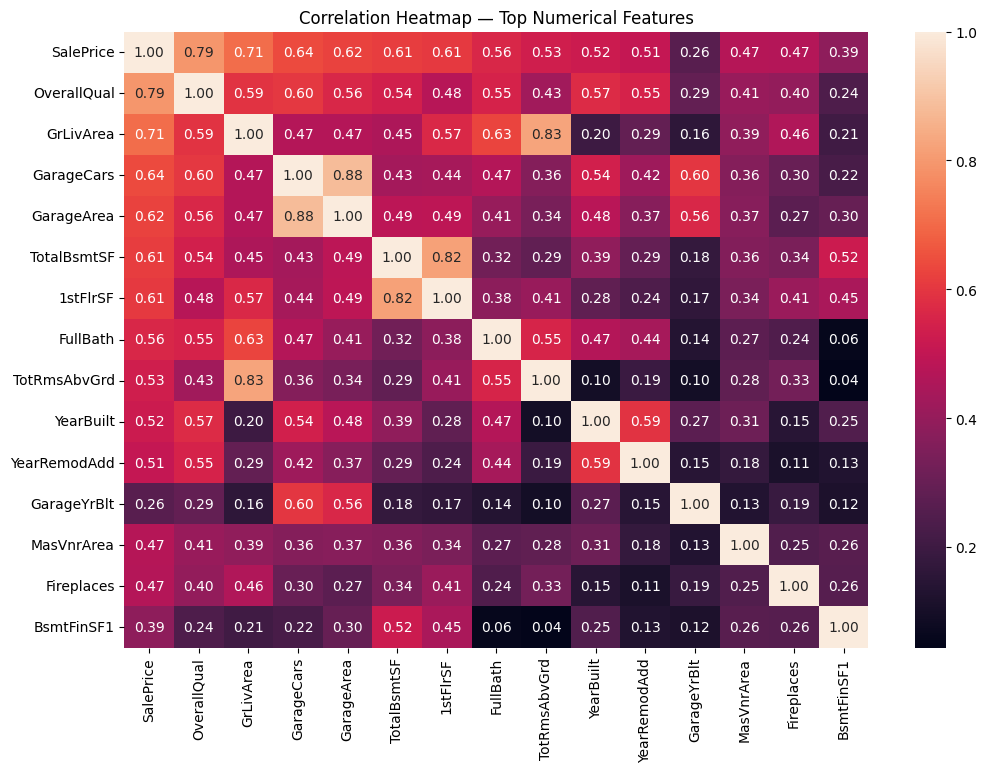

In [59]:
top_features = (
    correlations.abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    train[top_features].corr(),
    annot=True,
    fmt=".2f"
)

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.title("Correlation Heatmap — Top Numerical Features")
plt.show()

In [60]:
from google.colab import files

files.download("correlation_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Outlier Investigation

Outliers can strongly affect regression models.

We inspect the target distribution and investigate unusually large houses
and sale prices before deciding how to handle them.

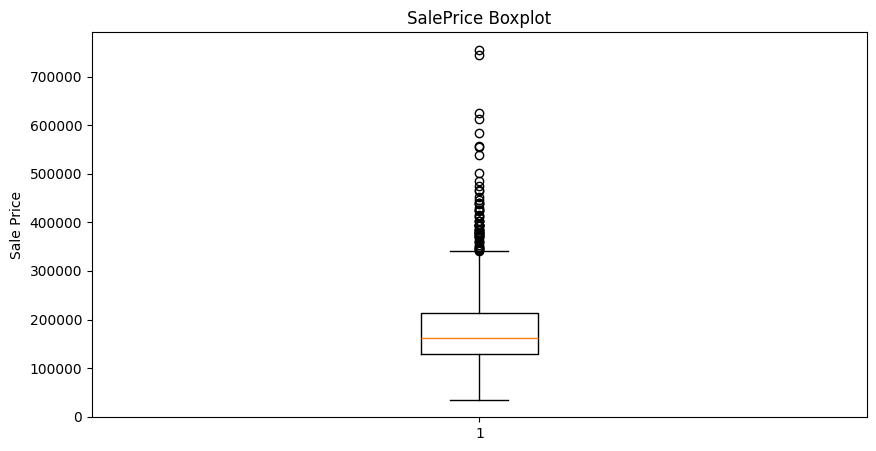

In [61]:
plt.figure(figsize=(10, 5))

plt.boxplot(train["SalePrice"])

plt.ylabel("Sale Price")
plt.title("SalePrice Boxplot")

plt.savefig("saleprice_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [62]:
from google.colab import files

files.download("saleprice_boxplot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
train[
    ["Id", "GrLivArea", "OverallQual", "SalePrice"]
].sort_values(
    "GrLivArea",
    ascending=False
).head(10)

,Id,GrLivArea,OverallQual,SalePrice
1298,1299,5642,10,160000
523,524,4676,10,184750
1182,1183,4476,10,745000
691,692,4316,10,755000
1169,1170,3627,10,625000
185,186,3608,10,475000
304,305,3493,7,295000
1268,1269,3447,8,381000
635,636,3395,6,200000
769,770,3279,8,538000


## 8. Understanding the Data Description

The `data_description.txt` file explains what each feature represents.

This is especially useful when interpreting missing values.

For example, a missing value in `PoolQC` means that the property does not
have a pool, rather than necessarily indicating an unknown value.

In [27]:
with open("data_description.txt", "r") as f:
    description = f.read()

print(description[:5000])

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [28]:
# Investigating Missing Values
for word in [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "LotFrontage",
    "GarageType",
    "BsmtQual"
]:
    print("\n" + "="*60)
    print(word)
    print("="*60)

    start = description.find(word)
    print(description[start:start+800])


PoolQC
PoolQC: Pool quality
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       NA	No Pool
		
Fence: Fence quality
		
       GdPrv	Good Privacy
       MnPrv	Minimum Privacy
       GdWo	Good Wood
       MnWw	Minimum Wood/Wire
       NA	No Fence
	
MiscFeature: Miscellaneous feature not covered in other categories
		
       Elev	Elevator
       Gar2	2nd Garage (if not described in garage section)
       Othr	Other
       Shed	Shed (over 100 SF)
       TenC	Tennis Court
       NA	None
		
MiscVal: $Value of miscellaneous feature

MoSold: Month Sold (MM)

YrSold: Year Sold (YYYY)

SaleType: Type of sale
		
       WD 	Warranty Deed - Conventional
       CWD	Warranty Deed - Cash
       VWD	Warranty Deed - VA Loan
       New	Home just constructed and sold
       COD	Court

MiscFeature
MiscFeature: Miscellaneous feature not covered in other categories
		
       Elev	Elevator
       Gar2	2nd Garage (if not described in garage section)
       Othr	Other
       Sh

In [29]:
train[["MasVnrType", "MasVnrArea"]].isnull().sum()

,0
MasVnrType,872
MasVnrArea,8


In [30]:
train[train["MasVnrType"].isnull()][
    ["MasVnrType", "MasVnrArea"]
].head(20)

,MasVnrType,MasVnrArea
1,NaN,0.0
3,NaN,0.0
5,NaN,0.0
8,NaN,0.0
9,NaN,0.0
10,NaN,0.0
12,NaN,0.0
15,NaN,0.0
17,NaN,0.0
18,NaN,0.0


## 10. Handling Missing Values

Missing values are handled according to the meaning of each feature.

### Categorical features
When a missing value means that a feature is absent, we use `"None"`.

### Numerical features
When a missing value represents the absence of a feature, we use `0`.

### LotFrontage
Missing values are filled using the median value within each neighborhood.

### GarageYrBlt
A missing value indicates that the property has no garage, so we use `0`.

### Electrical
The single missing value is replaced with the training-set mode.
   For `Electrical`, fill with the mode (most frequent value).

In [31]:
# Categorical: NaN means feature is absent
cat_none = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
            'GarageType','GarageFinish','GarageQual','GarageCond',
            'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']

for col in cat_none:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

# MasVnrType: NaN means no masonry veneer
train['MasVnrType'] = train['MasVnrType'].fillna('None').astype(str)
test['MasVnrType'] = test['MasVnrType'].fillna('None').astype(str)

# Numerical: NaN means feature is absent
num_zero = ['MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF',
            'TotalBsmtSF','BsmtFullBath','BsmtHalfBath','GarageArea','GarageCars']

for col in num_zero:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# LotFrontage: neighborhood median
for df in [train, test]:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())
test['LotFrontage'] = test['LotFrontage'].fillna(train['LotFrontage'].median())

# GarageYrBlt: no garage → 0
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)

# Electrical: fill with training mode
mode = train['Electrical'].mode()[0]
train['Electrical'] = train['Electrical'].fillna(mode)
test['Electrical'] = test['Electrical'].fillna(mode)

cols = ['MSZoning','Utilities','Exterior1st','Exterior2nd',
        'KitchenQual','Functional','SaleType']

for col in cols:
    mode = train[col].mode()[0]
    train[col] = train[col].fillna(mode)
    test[col] = test[col].fillna(mode)

# Check remaining missing values
print("Train missing:", train.isnull().sum().sum())
print("Test missing:", test.isnull().sum().sum())

Train missing: 0
Test missing: 0


## 11. Feature Engineering

We create additional features that summarize important characteristics
of each property.

### New features

- `TotalSF` — total basement and above-ground floor area
- `TotalBathrooms` — weighted total bathroom count
- `TotalPorchSF` — total porch/deck area
- `HouseAge` — age of the house at the time of sale
- `RemodAge` — years since the most recent remodeling

In [32]:
# TotalSF — total house/basement area
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

# TotalBathrooms
train['TotalBathrooms'] = (
    train['FullBath'] +
    0.5 * train['HalfBath'] +
    train['BsmtFullBath'] +
    0.5 * train['BsmtHalfBath']
)

test['TotalBathrooms'] = (
    test['FullBath'] +
    0.5 * test['HalfBath'] +
    test['BsmtFullBath'] +
    0.5 * test['BsmtHalfBath']
)

# TotalPorchSF
for df in [train, test]:
    df['TotalPorchSF'] = (
        df['OpenPorchSF'] +
        df['3SsnPorch'] +
        df['EnclosedPorch'] +
        df['ScreenPorch'] +
        df['WoodDeckSF']
    )

# HouseAge
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

# RemodAge
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
test['RemodAge'] = test['YrSold'] - test['YearRemodAdd']

print(train[['TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'HouseAge', 'RemodAge']].head())

   TotalSF  TotalBathrooms  TotalPorchSF  HouseAge  RemodAge
0     2566             3.5            61         5         5
1     2524             2.5           298        31        31
2     2706             3.5            42         7         6
3     2473             2.0           307        91        36
4     3343             3.5           276         8         8


## 12. Define Features and Target

`SalePrice` is the target variable.

All remaining columns are used as input features.

In [33]:
X = train.drop('SalePrice', axis=1)
y = train['SalePrice']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 85)
y shape: (1460,)


## 13. Train/Validation Split

We split the training data into:

- **80% training data**
- **20% validation data**

The validation set is used to evaluate model performance on unseen data.

In [34]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (1168, 85)
X_valid: (292, 85)
y_train: (1168,)
y_valid: (292,)


## 14. Preprocessing Pipeline

Machine learning models require numerical input.

We therefore create separate preprocessing pipelines:

### Numerical features
- Median imputation
- Standardization

### Categorical features
- Most-frequent imputation
- One-hot encoding

`ColumnTransformer` combines both pipelines into a single preprocessing system.

In [35]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 42
Categorical features: 43


## 15. Linear Regression — Baseline

Linear Regression provides a simple baseline model.

Its performance gives us a reference point for comparing more powerful
nonlinear models.

In [36]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrS...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [37]:
y_pred_lr = linear_model.predict(X_valid)

rmse_lr = np.sqrt(mean_squared_error(y_valid, y_pred_lr))
mae_lr = mean_absolute_error(y_valid, y_pred_lr)
r2_lr = r2_score(y_valid, y_pred_lr)

print(f"RMSE: ${rmse_lr:,.2f}")
print(f"MAE:  ${mae_lr:,.2f}")
print(f"R²:   {r2_lr:.4f}")

RMSE: $65,182.12
MAE:  $21,114.23
R²:   0.4461


## 16. Random Forest

Random Forest combines many decision trees to capture nonlinear relationships
between house characteristics and sale prices.

In [38]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrS...
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [39]:
y_pred_rf = rf_model.predict(X_valid)

rmse_rf = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
mae_rf = mean_absolute_error(y_valid, y_pred_rf)
r2_rf = r2_score(y_valid, y_pred_rf)

print(f"RMSE: ${rmse_rf:,.2f}")
print(f"MAE:  ${mae_rf:,.2f}")
print(f"R²:   {r2_rf:.4f}")

RMSE: $29,604.67
MAE:  $17,447.62
R²:   0.8857


## 17. XGBoost

XGBoost is a gradient-boosting algorithm that builds trees sequentially,
with each new tree learning from the errors of previous trees.

We use it as our main high-performance regression model.

In [40]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrS...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [41]:
y_pred_xgb = xgb_model.predict(X_valid)

rmse_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_xgb))
mae_xgb = mean_absolute_error(y_valid, y_pred_xgb)
r2_xgb = r2_score(y_valid, y_pred_xgb)

print(f"RMSE: ${rmse_xgb:,.2f}")
print(f"MAE:  ${mae_xgb:,.2f}")
print(f"R²:   {r2_xgb:.4f}")

RMSE: $25,625.96
MAE:  $15,437.03
R²:   0.9144


## 18. Model Comparison

We compare the three regression models using RMSE, MAE, and R².

For this project:

- Lower RMSE is better.
- Lower MAE is better.
- Higher R² is better.

In [42]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "R²": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

results.sort_values("RMSE")

,Model,RMSE,MAE,R²
2,XGBoost,25625.955592,15437.034180,0.914386
1,Random Forest,29604.668180,17447.620354,0.885737
0,Linear Regression,65182.124470,21114.225183,0.446085


## 19. XGBoost Hyperparameter Tuning

The initial XGBoost model uses manually selected parameters.

We now use `GridSearchCV` to search systematically for a better combination
of hyperparameters.

The search evaluates:

- Number of estimators
- Learning rate
- Maximum tree depth
- Subsample ratio
- Feature sampling ratio

We optimize for **Mean Absolute Error (MAE)** because MAE is directly related
to the average dollar prediction error.

In [43]:
param_grid = {
    'model__n_estimators': [300, 500, 700],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 4, 5],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train, y_train)

# Print the best parameters and best score
print("\n🏆 Grid Search Complete")
print("\nBest parameters found:", grid_search_xgb.best_params_)
print("Best RMSE found:", np.sqrt(-grid_search_xgb.best_score_))



Fitting 3 folds for each of 243 candidates, totalling 729 fits

🏆 Grid Search Complete

Best parameters found: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 700, 'model__subsample': 0.7}
Best RMSE found: 120.87608663549834


## 20. Evaluate the Tuned XGBoost Model

We evaluate the optimized model on the validation set using the same
three regression metrics.

In [44]:
best_xgb_model = grid_search_xgb.best_estimator_

y_pred_best_xgb = grid_search_xgb.best_estimator_.predict(X_valid)
rmse_best_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_best_xgb))
mae_best_xgb = mean_absolute_error(y_valid, y_pred_best_xgb)
r2_best_xgb = r2_score(y_valid, y_pred_best_xgb)

print(f"\nBest XGBoost Model (Validation Set):")
print(f"RMSE: ${rmse_best_xgb:,.2f}")
print(f"MAE:  ${mae_best_xgb:,.2f}")
print(f"R²:   {r2_best_xgb:.4f}")


Best XGBoost Model (Validation Set):
RMSE: $23,990.16
MAE:  $15,098.77
R²:   0.9250


## 21. Feature Importance

Feature importance helps us understand which variables contributed most
to the XGBoost model's predictions.

In [45]:
feature_names = best_xgb_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_xgb_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
4,num__OverallQual,0.115772
37,num__TotalSF,0.088673
176,cat__ExterQual_TA,0.054566
188,cat__BsmtQual_Ex,0.050499
237,cat__KitchenQual_TA,0.040411
26,num__GarageCars,0.039911
248,cat__FireplaceQu_None,0.036019
38,num__TotalBathrooms,0.027671
234,cat__KitchenQual_Ex,0.026816
56,cat__LandContour_Bnk,0.026653


## 22. Final Model

After selecting the best XGBoost configuration, we retrain the model using
the complete training dataset.

This allows the final model to learn from all available labeled observations
before generating predictions for the test dataset.

In [46]:
final_model = grid_search_xgb.best_estimator_
final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrS...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=700, n_jobs=-1,
                              num_parallel_tree=None, ...))])

## 23. Generate Test Predictions

The final model is now used to predict the `SalePrice` of the 1,459 houses
in the test dataset.

In [47]:
test_predictions = final_model.predict(test)

print(test_predictions[:10])
print("Number of predictions:", len(test_predictions))

[130674.37  163884.22  182826.64  193543.2   184563.61  178575.92
 182204.33  166659.31  185485.47  127019.984]
Number of predictions: 1459


## 24. Create Kaggle Submission

Kaggle requires a submission file containing:

- `Id`
- `SalePrice`

We create the submission DataFrame and save it as `submission.csv`.

In [48]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print("Shape:", submission.shape)

     Id      SalePrice
0  1461  130674.367188
1  1462  163884.218750
2  1463  182826.640625
3  1464  193543.203125
4  1465  184563.609375
Shape: (1459, 2)


## 25. Download Submission

The final `submission.csv` file is ready to upload to Kaggle.

In [49]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 26. Conclusion

This project developed a complete house price prediction pipeline using
the Ames Housing dataset.

### Key Steps

- Performed exploratory data analysis
- Investigated missing values and outliers
- Used `data_description.txt` to understand feature meanings
- Applied feature engineering
- Built a reusable preprocessing pipeline
- Compared Linear Regression, Random Forest, and XGBoost
- Tuned XGBoost using GridSearchCV
- Analyzed feature importance
- Trained the final model on the complete training dataset
- Generated predictions for the Kaggle test set

### Final Model

The tuned XGBoost model achieved:

- **RMSE: $23,990.16**

- **MAE: $15,098.77**

- **R²: 0.9250**

The final predictions were exported to `submission.csv` for Kaggle submission.

In [51]:
joblib.dump(final_model, "final_xgboost_model.pkl")

print("Final XGBoost pipeline saved successfully.")

Final XGBoost pipeline saved successfully.


In [50]:
joblib.dump(final_model, "final_xgboost_model.pkl")

['final_xgboost_model.pkl']

In [53]:
from google.colab import files

files.download("final_xgboost_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
# Get feature names after preprocessing
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# Get XGBoost feature importance
importance_values = final_model.named_steps["model"].feature_importances_

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Save as CSV
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

# Display top 10
feature_importance.head(10)

,Feature,Importance
0,num__OverallQual,0.133935
1,cat__BsmtQual_Ex,0.117006
2,num__TotalSF,0.100979
3,num__GarageCars,0.062091
4,cat__KitchenQual_TA,0.029079
5,num__TotalBathrooms,0.027796
6,cat__FireplaceQu_None,0.027587
7,cat__LandContour_Bnk,0.022474
8,cat__ExterQual_TA,0.021042
9,num__2ndFlrSF,0.016973


In [55]:
from google.colab import files

files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

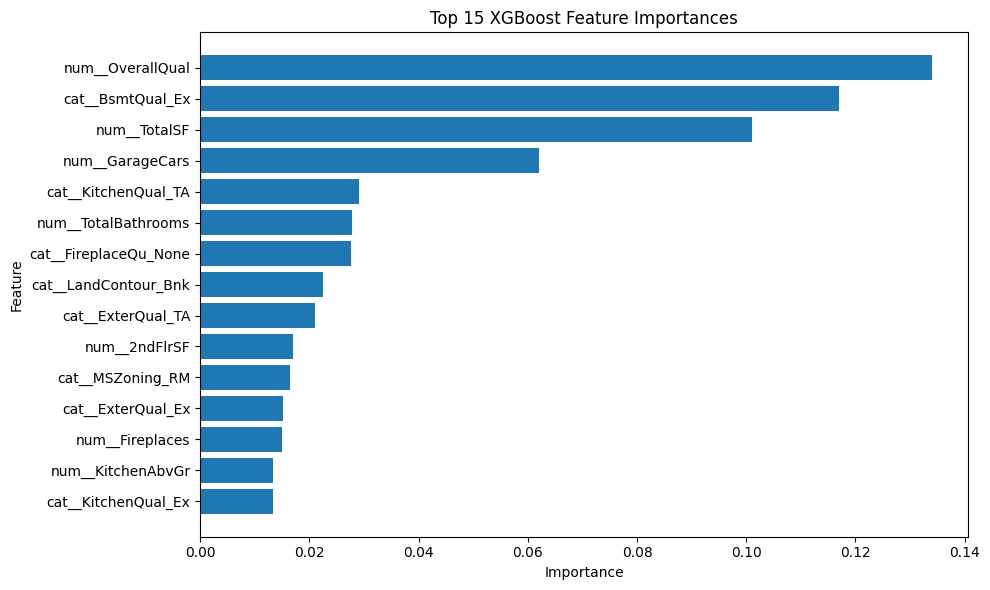

In [63]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature names
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# Get XGBoost importance
importance_values = final_model.named_steps["model"].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort and select top 15
feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(15)
)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
from google.colab import files

files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

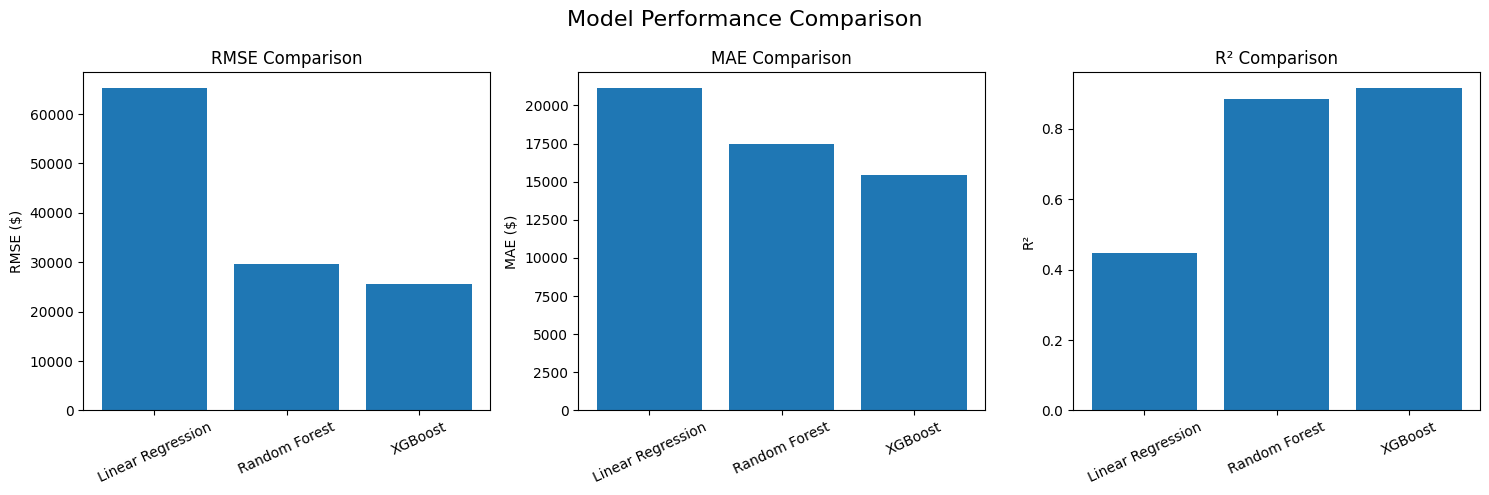

In [65]:
# Model Comparison

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "R²": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE
axes[0].bar(results["Model"], results["RMSE"])
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE ($)")
axes[0].tick_params(axis="x", rotation=25)

# MAE
axes[1].bar(results["Model"], results["MAE"])
axes[1].set_title("MAE Comparison")
axes[1].set_ylabel("MAE ($)")
axes[1].tick_params(axis="x", rotation=25)

# R²
axes[2].bar(results["Model"], results["R²"])
axes[2].set_title("R² Comparison")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=25)

plt.suptitle("Model Performance Comparison", fontsize=16)

plt.tight_layout()

# Save image
plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
from google.colab import files

files.download("model_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>